In [27]:
# Import Libraries
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # 0=all logs, 1=filter INFO, 2=filter WARNING, 3=filter ERROR
import cv2
import numpy as np
import json
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import classification_report, accuracy_score

In [8]:
# Parameters
IMG_SIZE = 128
DATA_PATH = "../Data/Scores"
BATCH_SIZE = 32
EPOCHS = 20

In [9]:
# Data Preparation
X, y, class_names = [], [], []
class_map = {}

print("[INFO] Loading dataset...")

for shape_name in os.listdir(DATA_PATH):  # e.g., Circle, Square, Triangle
    shape_path = os.path.join(DATA_PATH, shape_name)
    if not os.path.isdir(shape_path):
        continue
    
    for score in os.listdir(shape_path):  # e.g., 0, 1, 2, ...
        score_path = os.path.join(shape_path, score)
        if not os.path.isdir(score_path):
            continue
        
        label = f"{shape_name}_{score}"
        if label not in class_map:
            class_map[label] = len(class_map)
            class_names.append(label)
        
        for file in os.listdir(score_path):
            if file.endswith(".png") or file.endswith(".jpg"):
                path = os.path.join(score_path, file)
                img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                X.append(img)
                y.append(class_map[label])

X = np.array(X, dtype="float32") / 255.0
X = np.expand_dims(X, -1)   # shape = (N,128,128,1)
y = np.array(y)
y_cat = to_categorical(y, num_classes=len(class_map))

print(f"[INFO] Dataset loaded: {X.shape[0]} samples, {len(class_map)} classes")

[INFO] Loading dataset...


In [10]:
# Train/test split
print("[INFO] Splitting dataset...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42
)
print(f"[INFO] Train: {X_train.shape}, Test: {X_test.shape}")

[INFO] Splitting dataset...
[INFO] Train: (3437, 128, 128, 1), Test: (860, 128, 128, 1)


In [11]:
print("[INFO] Classes:", class_names)

[INFO] Dataset loaded: 4297 samples, 34 classes
[INFO] Classes: ['Triangle_0', 'Triangle_4', 'Triangle_5', 'Star_3', 'Star_2', 'Star_0', 'Star_4', 'Star_5', 'Wave_3', 'Wave_2', 'Wave_0', 'Wave_4', 'Circle_3', 'Circle_2', 'Circle_0', 'Circle_4', 'Square_0', 'Square_4', 'Square_5', 'Overlapped pencils_3', 'Overlapped pencils_2', 'Overlapped pencils_0', 'Overlapped pencils_4', 'Overlapped pencils_6', 'Overlapped pencils_5', 'Overlapped circle_2', 'Overlapped circle_0', 'Overlapped circle_4', 'Overlapped circle_6', 'Overlapped circle_5', 'Diagonal_3', 'Diagonal_0', 'Diagonal_4', 'Diagonal_5']


In [12]:
# Global CNN Model/ model build
base = EfficientNetB0(include_top=False, input_shape=(128,128,1), weights=None)

model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(len(class_map), activation="softmax")
])

model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

print(model.summary())

2025-10-07 17:02:12.600747: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [13]:
# Training
print("[INFO] Training model...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

[INFO] Training model...
Epoch 1/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.1602 - loss: 3.0458 - val_accuracy: 0.0828 - val_loss: 2.8430
Epoch 2/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.4579 - loss: 1.9821 - val_accuracy: 0.1163 - val_loss: 2.9192
Epoch 3/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.6273 - loss: 1.2301 - val_accuracy: 0.1163 - val_loss: 3.3319
Epoch 4/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.6987 - loss: 0.9282 - val_accuracy: 0.0828 - val_loss: 3.7105
Epoch 5/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.7558 - loss: 0.7198 - val_accuracy: 0.0785 - val_loss: 3.4823
Epoch 6/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.7771 - loss: 0.6569 - val_accuracy: 0.2166 - val_loss: 2.9858
Epoch 7/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8136 - loss: 0.5443 - val_accuracy: 0.4201 - val_loss: 2.4276
Epoch 8/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.8561 - loss: 0.4487 -

In [28]:
# Evaluation
print("[INFO] Evaluating model...")
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {acc:.4f}")

print(classification_report(
    y_true, y_pred_classes,
    labels=np.arange(len(class_map)),
    target_names=class_names
))

[INFO] Evaluating model...
Test Accuracy: 0.6628


NameError: name 'y_true' is not defined

In [15]:
# Prediction Helper
def decode_prediction(pred_idx):
    return class_names[pred_idx]

In [16]:
# Plot training & validation accuracy/loss
def plot_training(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # Accuracy
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Loss
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

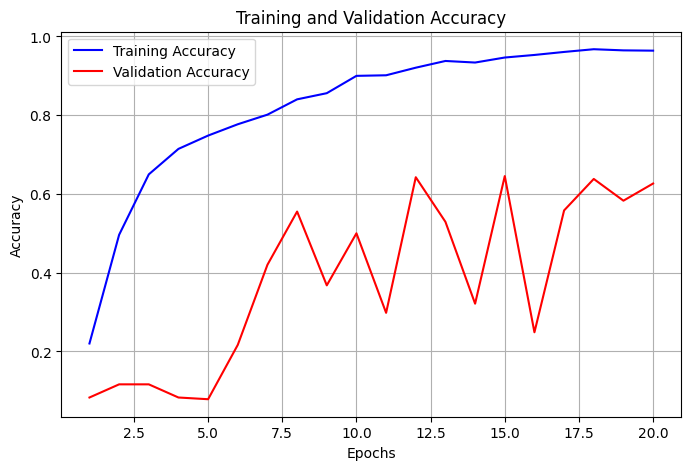

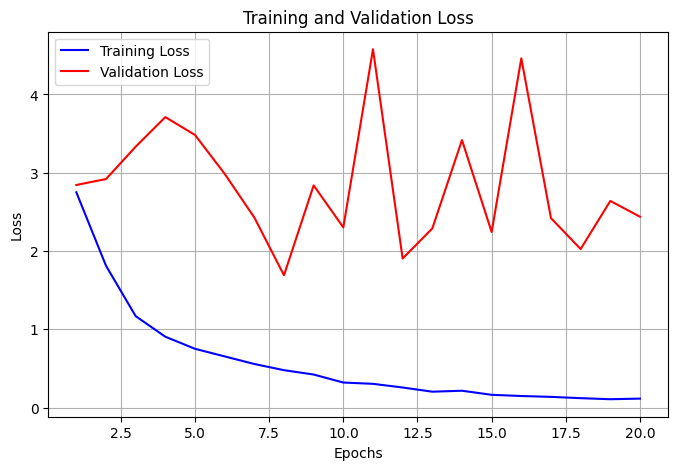

In [17]:
# Call after training
plot_training(history)

In [18]:
# Save directory
SAVE_DIR = "./model_outputs/CNN"
os.makedirs(SAVE_DIR, exist_ok=True)

In [19]:
# Save
pd.DataFrame(history.history).to_csv("global_cnn_training_history.csv", index=False)

In [23]:
# Save Model
model.save("global_cnn_model.h5")
print("[INFO] Model saved as global_cnn_model.h5")

[INFO] Model saved as global_cnn_model.h5


In [24]:
# Save training history as JSON
with open(os.path.join(SAVE_DIR, "training_history_CNN.json"), "w") as f:
    json.dump(history.history, f)
print("[INFO] Training history saved as JSON")

[INFO] Training history saved as JSON


In [25]:
# Accuracy Plot
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "accuracy_plot.png"))
plt.close()

In [26]:
# Save Loss Plot
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "loss_plot.png"))
plt.close()